In [1]:
import numpy as np
import itertools
import matplotlib.pyplot as plt
from InfAdjFPFiniteDiffApp import InfAdjFPFiniteDiff_Larsson

In [2]:
dim = 2
M = 1e-2
p = 4
v0 = 1.7e-14 * M ** 4 # 多田さんのノートの式

def infPotFunc(phi):
    r = np.linalg.norm(phi)
    return v0 * (1 - (r / M) ** p) ** 2

def infPotDerivFunc(phi, i):
    r = np.linalg.norm(phi)
    return -2 * p * v0 / M / M * (1 - (r / M) ** p) * (r / M) ** (p - 2) * phi[i]

def infPotDeriv2Func(phi, i, j):
    r = np.linalg.norm(phi)
    return 2 * p * v0 / (M ** 4) * ((2 * p - 1) * (r / M) ** p - p + 1) * (r / M) ** (p - 4) * phi[i] * phi[j] \
           - 2 * p * v0 / M / M / M / M * (1 - (r / M) ** p) * (r / M) ** (p - 4) * ((int)(i == j) * r * r - phi[i] * phi[j])

infPotentialDerivFuncs = [lambda phi: infPotDerivFunc(phi, i) for i in range(dim)]
infPotentialDeriv2Funcs = [lambda phi: infPotDeriv2Func(phi, i, j) for i, j in np.ndindex((dim, dim))]

nGrid = 64
upperBound = (M * M / 2 / p / (p - 1)) ** (1 / (p - 2)) * M
lowerBound = -upperBound

In [3]:
grids1d = np.linspace(lowerBound, upperBound, nGrid, endpoint=False)
grids = np.array([np.array(g) for g in itertools.product(grids1d, grids1d)])

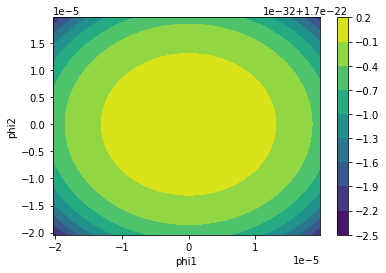

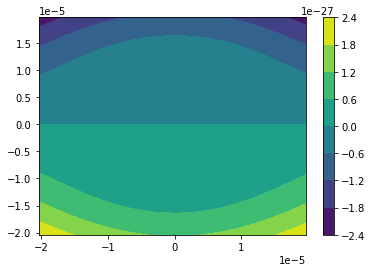

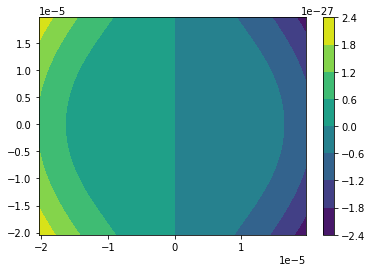

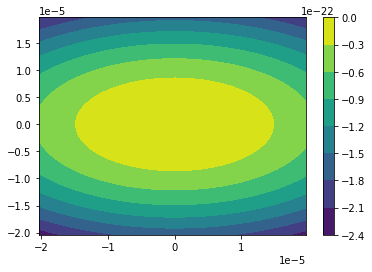

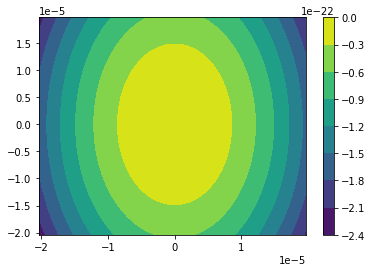

In [4]:
# ポテンシャルとその微分
fig, ax1 = plt.subplots(1)
vVec = [infPotFunc(grid) for grid in grids]
cntr1 = ax1.contourf(grids1d, grids1d, np.reshape(vVec, (nGrid, nGrid)))
fig.colorbar(cntr1, ax=ax1)
ax1.set_xlabel("phi1")
ax1.set_ylabel("phi2")
plt.show()

fig, ax1 = plt.subplots(1)
vDerPhi1Vec = [infPotDerivFunc(grid, 0) for grid in grids]
cntr1 = ax1.contourf(grids1d, grids1d, np.reshape(vDerPhi1Vec, (nGrid, nGrid)))
fig.colorbar(cntr1, ax=ax1)
plt.show()

fig, ax1 = plt.subplots(1)
vDerPhi2Vec = [infPotDerivFunc(grid, 1) for grid in grids]
cntr1 = ax1.contourf(grids1d, grids1d, np.reshape(vDerPhi2Vec, (nGrid, nGrid)))
fig.colorbar(cntr1, ax=ax1)
plt.show()

fig, ax1 = plt.subplots(1)
vDer2Phi1Vec = [infPotDeriv2Func(grid, 0, 0) for grid in grids]
cntr1 = ax1.contourf(grids1d, grids1d, np.reshape(vDer2Phi1Vec, (nGrid, nGrid)))
fig.colorbar(cntr1, ax=ax1)
plt.show()

fig, ax1 = plt.subplots(1)
vDer2Phi2Vec = [infPotDeriv2Func(grid, 1, 1) for grid in grids]
cntr1 = ax1.contourf(grids1d, grids1d, np.reshape(vDer2Phi2Vec, (nGrid, nGrid)))
fig.colorbar(cntr1, ax=ax1)
plt.show()

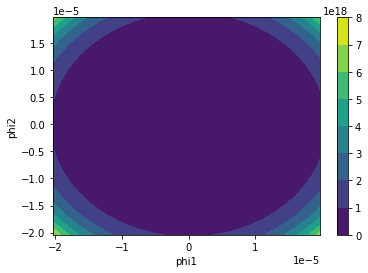

In [5]:
# 非微分項
nonDerivTerms = []

for grid in grids:
    v = infPotFunc(grid) / (24 * np.pi * np.pi)
    nonDerivTerm = 0
    for iDim in range(dim):
        vDer = infPotDerivFunc(grid, iDim)
        vDer2 = infPotDeriv2Func(grid, iDim, iDim)
        nonDerivTerm -= (2 * v * v * (1 + v) * vDer2 - (1 + 4 * v + v * v) * vDer * vDer) / (4 * v * v * v)
    nonDerivTerms.append(nonDerivTerm)

fig, ax1 = plt.subplots(1)
cntr1 = ax1.contourf(grids1d, grids1d, np.reshape(nonDerivTerms, (nGrid, nGrid)))
fig.colorbar(cntr1, ax=ax1)
ax1.set_xlabel("phi1")
ax1.set_ylabel("phi2")
plt.show()

In [6]:
fpFinDiff = InfAdjFPFiniteDiff_Larsson(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    infPotentialDeriv2Funcs,
    nGrid,
    upperBound,
    lowerBound
)

In [7]:
fpFinDiff

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [8]:
# 微分演算子の離散化行列中、0にセットされていない行・列の位置
nonzeroId = np.array([np.any(np.abs(row) > 1e-50) for row in fpFinDiff])

In [11]:
# 0の行・列を除いて固有値求める
fpFinDiffWoZeroRowCol = fpFinDiff[np.ix_(nonzeroId, nonzeroId)]
eigVals, eigVecs = np.linalg.eig(fpFinDiffWoZeroRowCol)
eigVecsTemp = eigVecs.T[np.argsort(eigVals)]
eigValsSort = np.sort(eigVals)

# 固有ベクトルには、行列から除いた行・列に対応するグリッド点の位置に0を挿入する
nGridTot = nGrid ** dim
eigVecsSort = []
for eTemp in eigVecsTemp:
    eSort = np.zeros(nGridTot)
    eSort[nonzeroId] = eTemp
    eigVecsSort.append(eSort)

<ipython-input-11-bd6b2084592a>:12: ComplexWarning: Casting complex values to real discards the imaginary part
  eSort[nonzeroId] = eTemp


c:\Users\koich\anaconda3\lib\site-packages\numpy\core\_asarray.py:102: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


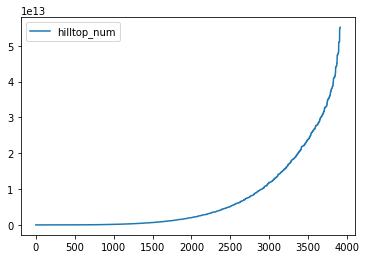

In [12]:
ax = plt.gca()
plt.plot(eigValsSort, label = "hilltop_num")
plt.legend()
plt.show()

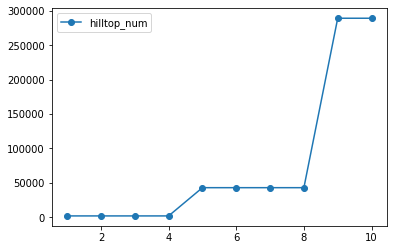

In [13]:
ax = plt.gca()
plt.plot(np.arange(1, 11), eigValsSort[:10], marker='o', label = "hilltop_num")
plt.legend()
plt.show()

In [14]:
print(eigValsSort[:30])

[1.71063852e+03+0.00000000e+00j 1.71063853e+03+0.00000000e+00j
 1.71063853e+03+0.00000000e+00j 1.71063855e+03+0.00000000e+00j
 4.27659563e+04+0.00000000e+00j 4.27659564e+04+0.00000000e+00j
 4.27659564e+04-5.34789989e-06j 4.27659564e+04+5.34789989e-06j
 2.89097861e+05+0.00000000e+00j 2.89097861e+05+0.00000000e+00j
 2.89097861e+05-4.12512444e-05j 2.89097861e+05+4.12512444e-05j
 3.84893601e+05+0.00000000e+00j 3.84893601e+05+0.00000000e+00j
 3.84893601e+05+0.00000000e+00j 3.84893601e+05+0.00000000e+00j
 1.06914889e+06+0.00000000e+00j 1.06914889e+06-5.11991971e-06j
 1.06914889e+06+5.11991971e-06j 1.06914889e+06+0.00000000e+00j
 1.24705526e+06+0.00000000e+00j 1.24705526e+06+0.00000000e+00j
 1.24705526e+06+0.00000000e+00j 1.24705526e+06+0.00000000e+00j
 2.87558285e+06+0.00000000e+00j 2.87558285e+06+0.00000000e+00j
 2.87558285e+06+0.00000000e+00j 2.87558285e+06+0.00000000e+00j
 4.44937001e+06+0.00000000e+00j 4.44937001e+06+0.00000000e+00j]


考えている$\phi$の領域をちょうど覆うようなGaussianを試行ベクトルに取り、固有ベクトルで展開

In [15]:
sigma = (upperBound - lowerBound) / 6.0
mu = 0.5 * (upperBound + lowerBound)
trialVec = np.array([np.exp(- 0.5 * np.sum((g - mu) ** 2) / sigma ** 2) for g in grids])
trialVec /= np.linalg.norm(trialVec)

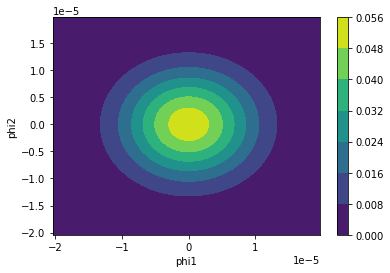

In [16]:
fig, ax1 = plt.subplots(1)
cntr1 = ax1.contourf(grids1d, grids1d, np.reshape(trialVec, (nGrid, nGrid)))
fig.colorbar(cntr1, ax=ax1)
ax1.set_xlabel("phi1")
ax1.set_ylabel("phi2")
plt.show()

In [17]:
contriEachEigVec = [np.dot(trialVec, ev) ** 2 for ev in eigVecsSort]

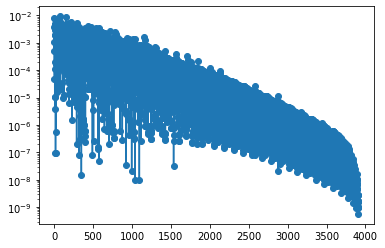

In [18]:
# 各固有ベクトルの寄与度
ax = plt.gca()
plt.plot(contriEachEigVec, marker='o')
plt.yscale('log')
plt.show()

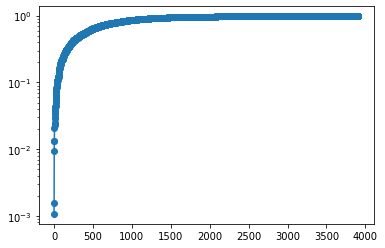

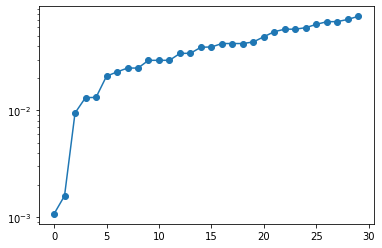

In [22]:
# 各固有ベクトルの寄与度（累積）
ax = plt.gca()
plt.plot(np.cumsum(contriEachEigVec), marker='o')
plt.yscale('log')
plt.show()

plt.plot(np.cumsum(contriEachEigVec)[:30], marker='o')
plt.yscale('log')
plt.show()

In [20]:
from mpl_toolkits.mplot3d import Axes3D

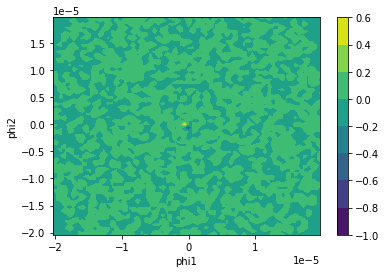

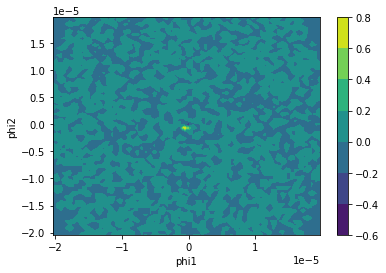

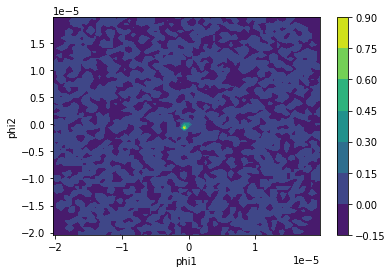

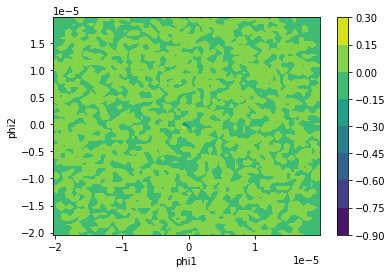

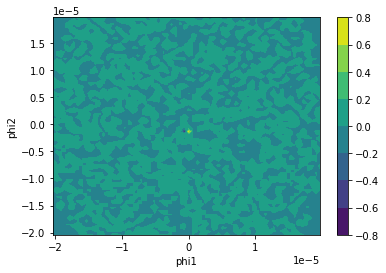

In [21]:
# 固有関数のプロット
for iEig in range(5):   
    fig, ax1 = plt.subplots(1)
    cntr1 = ax1.contourf(grids1d, grids1d, np.reshape(eigVecsSort[iEig], (nGrid, nGrid)))
    fig.colorbar(cntr1, ax=ax1)
    ax1.set_xlabel("phi1")
    ax1.set_ylabel("phi2")
    plt.show()